# Classification Pipeline (Steps 8, 9, 11)

Builds the classification training dataset from `data/processed/metadata.csv`.

**Prerequisite:** run `data-preparation.ipynb` first.

**Outputs:**
- `data/processed/classification_data/{train,val,test}/<Species>/*.jpg` (raw copies)
- `data/processed/classification_data_aug/{train,val,test}/<Species>/*.jpg` (with augmentation on train)


In [13]:
import shutil
import random
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm import tqdm

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

def safe(name):
    """Filesystem-friendly name: replace spaces and path separators."""
    return str(name).replace(" ", "_").replace("/", "_").replace(":", "_")

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}

PROCESSED_DIR = Path("data/processed")
RAW_DIR = Path("data/raw")
CLASSIFICATION_DIR = PROCESSED_DIR / "classification_data"
CLASSIFICATION_DIR.mkdir(parents=True, exist_ok=True)

# IMPORTANT: must match data-preparation.ipynb for class-id consistency.
TARGET_SPECIES = [
    'Amanita muscaria',
    'Boletus edulis',
    'Cantharellus cibarius',
    'Pleurotus ostreatus',
    'Agaricus bisporus',
    'Laetiporus sulphureus',
    'Morchella esculenta',
    'Coprinus comatus',
]


In [14]:
metadata = pd.read_csv(PROCESSED_DIR / 'metadata.csv')
print(f'Loaded metadata: {len(metadata)} rows from {PROCESSED_DIR / "metadata.csv"}')
print(f'  Species: {sorted(metadata["canonical_species"].unique())}')
print(f'  Splits: {metadata["split"].value_counts().to_dict()}')


Loaded metadata: 2839 rows from data/processed/metadata.csv
  Species: ['Agaricus bisporus', 'Amanita muscaria', 'Boletus edulis', 'Cantharellus cibarius', 'Coprinus comatus', 'Laetiporus sulphureus', 'Morchella esculenta', 'Pleurotus ostreatus']
  Splits: {'train': 1987, 'test': 426, 'val': 426}


## 8. Build the classification dataset

Copies every image into `processed/classification_data/{split}/{Species}/` — the layout `torchvision.datasets.ImageFolder` expects.


In [15]:

for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc='copying'):
    src = Path(row['image_path'])
    species = safe(row['canonical_species'])
    dst = CLASSIFICATION_DIR / row['split'] / species / f'{src.stem}{src.suffix.lower()}'
    dst.parent.mkdir(parents=True, exist_ok=True)
    if not dst.exists():
        shutil.copy2(src, dst)

print(f'Classification dataset at: {CLASSIFICATION_DIR.resolve()}')
for split in ['train', 'val', 'test']:
    n = sum(1 for f in (CLASSIFICATION_DIR / split).rglob('*') if f.is_file())
    print(f'  {split}: {n} images')


copying: 100%|██████████| 2839/2839 [00:00<00:00, 26601.56it/s]

Classification dataset at: /Users/phicks/Workspace/projects/M8F_IntelligentEmbeddedSystem_Project/data/processed/classification_data
  train: 1987 images
  val: 426 images
  test: 426 images


## 9. Resize and augment training data (v3 - Albumentations)

Resize every image to 224x224 and augment the training set using [Albumentations](https://albumentations.ai/). The val and test sets are resized only (no augmentation) so evaluation is deterministic.

For each original training image, the step writes (to a new directory `data/processed/classification_data_aug/`, **NOT** overwriting the raw copies in `classification_data/`):

- val/test: 1 resized 224x224 image
- train: `AUG_PER_IMAGE` augmented copies (`<stem>_aug1.jpg`, `<stem>_aug2.jpg`, ...)

Augmentation pipeline (Albumentations) for the training set:

- `RandomResizedCrop(224, 224, scale=(0.7, 1.0), ratio=(0.85, 1.15), p=1.0)` - force the model to focus on local features (gills, cap, stem)
- `HorizontalFlip(p=0.5)` - mushrooms are roughly left/right symmetric
- `Rotate(limit=15, border_mode=cv2.BORDER_REFLECT_101, p=1.0)` - small rotation; reflection border avoids the white-fill artifact
- `ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.0, p=0.5)` - **no hue jitter** (color is diagnostic for mushroom species)
- `GaussianBlur(blur_limit=(3, 3), p=0.2)` - handles shallow depth-of-field macro photos

Val/test pipeline is just `Resize(IMAGE_SIZE, IMAGE_SIZE)` (deterministic).

Mushroom-specific tuning notes:

- Rotation is **15 deg, not 30**. Mushrooms have a clear gravity-defined orientation; large rotations create non-realistic training images.
- Hue jitter is **removed**. A small hue shift can turn red `Amanita muscaria` orange or yellow `Cantharellus cibarius` green - exactly the signal we want to preserve.
- Rotation border is `BORDER_REFLECT_101` (not constant white), so the rotated image keeps natural-looking edges with no "augmentation signature" the model could learn.
- Augmentations are applied at **original resolution**, then the augmented image is resized/cropped to 224x224. This is the standard "augment on full-resolution, then resize" approach.
- The raw copies under `data/processed/classification_data/` are **not** modified. The detection dataset (Step 10) still uses those original copies.
- The detection dataset (Step 10) is **not** modified by this step.

### Why Albumentations

Albumentations is the de-facto standard for object-detection augmentation pipelines and is used by the YOLOv5/v8/v11 training wrappers this project is also targeting. It has first-class bounding-box support (via `bbox_params`), configurable rotation border modes (so we can use `BORDER_REFLECT_101` instead of white fill), and a clean `Compose` API that mixes geometric and color transforms. When the detection dataset gets real bboxes later, the same `Compose` will handle them with a one-line `bbox_params` addition.

### Future: enabling bbox transforms

When real bboxes exist, add `bbox_params=A.BboxParams(format='pascal_voc', min_area=0, min_visibility=0, label_fields=['class_labels'])` to each `Compose` and pass `bboxes=[...]` and `class_labels=[...]` to `pipeline(image=img, bboxes=..., class_labels=..., seed=...)`. The transforms above will then be applied to bboxes consistently.

In [16]:
%pip install albumentations

import albumentations as A
import cv2

IMAGE_SIZE = 224
AUG_PER_IMAGE = 3
ROTATION_DEG = 15
BLUR_PROB = 0.2
COLOR_JITTER = 0.1
CROP_SCALE = (0.7, 1.0)
CROP_RATIO = (0.85, 1.15)

# Augmented data is written to a parallel directory so the raw copies in
# classification_data/ are never modified. Idempotent: existing files in
# the destination are skipped.
CLASSIFICATION_AUG_DIR = PROCESSED_DIR / 'classification_data_aug'

# Train: geometric + color + blur. p=1.0 on RandomResizedCrop and Rotate to
# ensure the model always sees crops and slight rotations (no untransformed
# baseline in the train set). When the detection dataset gets real bboxes,
# add bbox_params=A.BboxParams(format='pascal_voc', min_area=0,
# min_visibility=0, label_fields=['class_labels']) to each Compose.
train_pipeline = A.Compose([
    A.RandomResizedCrop(size=(IMAGE_SIZE, IMAGE_SIZE), scale=CROP_SCALE, ratio=CROP_RATIO, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=ROTATION_DEG, border_mode=cv2.BORDER_REFLECT_101, p=1.0),
    A.ColorJitter(brightness=COLOR_JITTER, contrast=COLOR_JITTER, saturation=COLOR_JITTER, hue=0.0, p=0.5),
    A.GaussianBlur(blur_limit=(3, 3), p=BLUR_PROB),
])

# Val/test: deterministic resize only. No augmentation.
val_pipeline = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
])


def _augment_image(img_rgb, pipeline, rng):
    """Apply pipeline deterministically via global numpy seed."""
    np.random.seed(rng.randint(0, 2**31 - 1))
    return pipeline(image=img_rgb)['image']


def _process_split(src_dir, dst_dir, pipeline, n_aug, seed):
    """Read images from src_dir, write augmented copies to dst_dir. Idempotent.

    Returns the total number of valid image files in dst_dir after the run
    (not just newly written in this run), so re-runs report the true
    dataset size instead of `0 images`.
    """
    if not src_dir.exists():
        return 0
    dst_dir.mkdir(parents=True, exist_ok=True)
    rng = random.Random(seed)

    species_dirs = sorted(d for d in src_dir.iterdir() if d.is_dir())
    for species_dir in tqdm(species_dirs, desc=f"{dst_dir.name}/species"):
        out_species = dst_dir / species_dir.name
        out_species.mkdir(parents=True, exist_ok=True)
        img_paths = sorted(
            p for p in species_dir.iterdir()
            if p.suffix.lower() in IMAGE_EXTS and "_aug" not in p.stem
        )
        for img_path in tqdm(img_paths, desc=f"  {species_dir.name}", leave=False):
            try:
                with Image.open(img_path) as raw:
                    pil_full = raw.convert("RGB")
                    img_rgb = np.array(pil_full)
                stem = img_path.stem
                ext = img_path.suffix.lower() if img_path.suffix.lower() in IMAGE_EXTS else ".jpg"

                if n_aug > 0:
                    for k in range(1, n_aug + 1):
                        out_path = out_species / f"{stem}_aug{k}{ext}"
                        if out_path.exists():
                            continue
                        aug_rgb = _augment_image(img_rgb, pipeline, rng)
                        Image.fromarray(aug_rgb).save(out_path, quality=95)
                else:
                    out_path = out_species / f"{stem}{ext}"
                    if out_path.exists():
                        continue
                    aug_rgb = _augment_image(img_rgb, pipeline, rng)
                    Image.fromarray(aug_rgb).save(out_path, quality=95)
            except Exception as e:
                import traceback
                print(f"  Failed on {img_path}: {e}")
                traceback.print_exc()
                continue
    # Report the on-disk file count so re-runs (all files already written)
    # show the true dataset size, not just files written in this run.
    return sum(1 for p in dst_dir.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXTS)


CLASSIFICATION_AUG_DIR.mkdir(parents=True, exist_ok=True)
counts = {}
for split, n_aug, pipeline, seed in (
    ('train', AUG_PER_IMAGE, train_pipeline, 42),
    ('val',   0,              val_pipeline,   43),
    ('test',  0,              val_pipeline,   44),
):
    counts[split] = _process_split(
        src_dir=CLASSIFICATION_DIR / split,
        dst_dir=CLASSIFICATION_AUG_DIR / split,
        pipeline=pipeline,
        n_aug=n_aug,
        seed=seed,
    )

print(f"Augmented classification dataset at: {CLASSIFICATION_AUG_DIR.resolve()}")
for split, n in counts.items():
    print(f"  {split}: {n} images")


/Users/phicks/Workspace/projects/M8F_IntelligentEmbeddedSystem_Project/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


test/species: 100%|██████████| 8/8 [00:02<00:00,  3.01it/s]

Augmented classification dataset at: /Users/phicks/Workspace/projects/M8F_IntelligentEmbeddedSystem_Project/data/processed/classification_data_aug
  train: 5961 images
  val: 426 images
  test: 426 images


## 11. Explore the data

Two visualizations:

- **Per-species per-dataset count matrix** - how many images each species has from each source (iNaturalist, GBIF, etc.)
- **3-column image grid** - for each species (up to 6 shown), three side-by-side images:
  - **original**: raw image from `data/raw/<source>/<Species>/`
  - **preprocessed**: same image after resize to 224x224 (the input size for MobileNetV4)
  - **augmented**: one of the 3 augmented training copies (with flip + rotation + blur + color jitter applied)


dataset,df20,gbif,inaturalist
canonical_species,,,
Agaricus bisporus,33,37,97
Amanita muscaria,199,99,99
Boletus edulis,200,99,100
Cantharellus cibarius,200,99,100
Coprinus comatus,199,100,99
Laetiporus sulphureus,200,97,100
Morchella esculenta,84,99,100
Pleurotus ostreatus,200,100,99


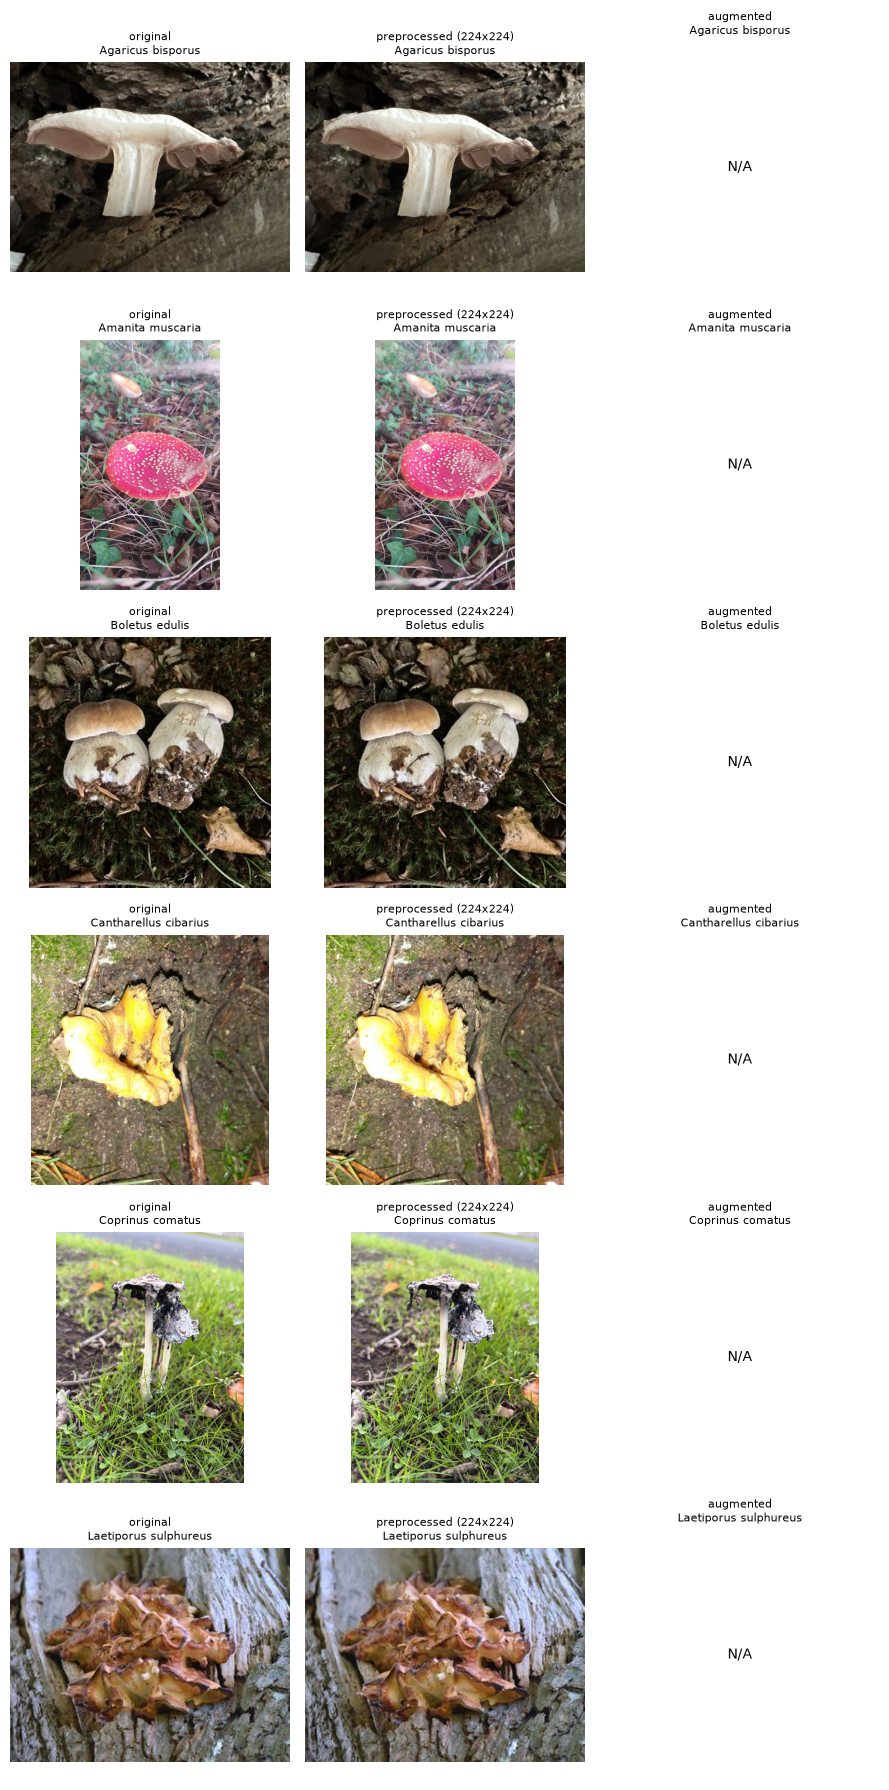

In [17]:
# 11.1 Per-species / per-dataset count matrix
display(metadata.groupby(['canonical_species', 'dataset']).size().unstack(fill_value=0))

# 11.2 Sample image grid: original | preprocessed (224x224) | augmented
# All three columns show the SAME image at different stages of the pipeline.
# Strategy: pick a random preprocessed file from classification_data/train/<Species>/,
# then look up its original in data/raw/<source>/<Species>/, then pick its _aug1 sibling.
species_list = sorted(metadata['canonical_species'].unique())[:6]
random.seed(42)
fig, axes = plt.subplots(len(species_list), 3, figsize=(9, 3 * len(species_list)))
if len(species_list) == 1:
    axes = [axes]
for row, species in enumerate(species_list):
    species_safe = species.replace(' ', '_')
    cls_species_dir = CLASSIFICATION_DIR / 'train' / species_safe
    preproc_path = None
    if cls_species_dir.exists():
        candidates = [f for f in cls_species_dir.iterdir()
                      if f.suffix.lower() in IMAGE_EXTS and '_aug' not in f.stem]
        if candidates:
            preproc_path = random.choice(candidates)
    orig_path = None
    if preproc_path:
        src_stem = preproc_path.stem
        for raw_source_dir in RAW_DIR.iterdir():
            if not raw_source_dir.is_dir():
                continue
            candidate = raw_source_dir / species_safe / f'{src_stem}{preproc_path.suffix.lower()}'
            if candidate.exists():
                orig_path = candidate
                break
    aug_path = None
    if preproc_path:
        candidate = preproc_path.parent / f'{preproc_path.stem}_aug1.jpg'
        if candidate.exists():
            aug_path = candidate
    for col, (label, p) in enumerate([('original', orig_path), ('preprocessed (224x224)', preproc_path), ('augmented', aug_path)]):
        ax = axes[row][col] if len(species_list) > 1 else axes[col]
        if p and Path(p).exists():
            try:
                img = Image.open(p)
                ax.imshow(img)
            except Exception:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
        ax.set_title(f"{label}\n{species}", fontsize=8)
        ax.axis('off')
plt.tight_layout()
plt.show()
